In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from keras.src.layers import BatchNormalization
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

2026-05-09 16:05:16.077263: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-09 16:05:16.331860: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-09 16:05:18.066334: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
X, y = make_circles(n_samples=100, noise=0.1, random_state=1)

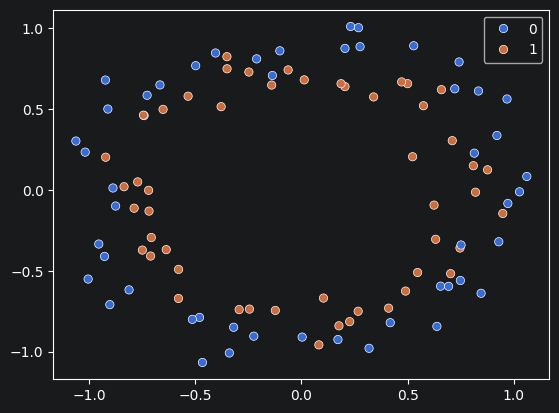

In [3]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [5]:
model = Sequential()
model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/home/opera/miniconda3/envs/tf-gpu/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1778342720.393207    1863 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5262 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0


In [6]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [7]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    verbose=0
)

2026-05-09 16:05:22.417937: I external/local_xla/xla/service/service.cc:153] XLA service 0x71f3d4008c60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-09 16:05:22.417957: I external/local_xla/xla/service/service.cc:161]   StreamExecutor device (0): NVIDIA GeForce RTX 5050 Laptop GPU, Compute Capability 12.0
2026-05-09 16:05:22.441786: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778342722.649930    1944 cuda_dnn.cc:530] Loaded cuDNN version 92101
2026-05-09 16:05:22.674776: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-05-09 16:05:22.674819: W external/local_xla/xla/ser

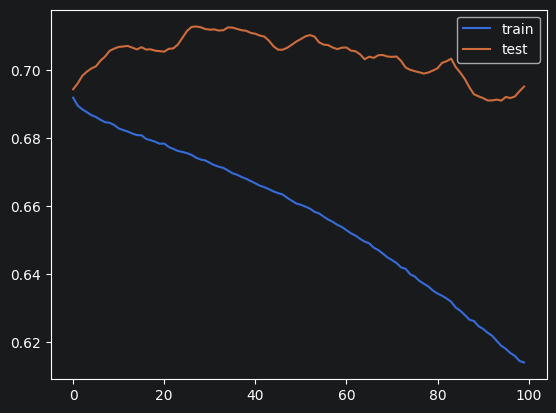

In [8]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 744us/step


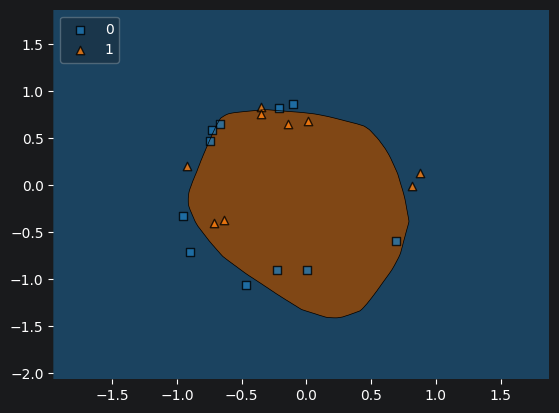

In [9]:
plot_decision_regions(X_test, y_test.ravel(), clf=model, legend=2)
plt.show()

Early Stopping  Applied here

In [10]:
model = Sequential()

model.add(Dense(48, input_dim=2, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(32, input_dim=2, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(16, input_dim=2, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(8, input_dim=2, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(2, input_dim=2, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1, activation='sigmoid'))

/home/opera/miniconda3/envs/tf-gpu/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [12]:
callback = EarlyStopping(
    monitor='val_loss',
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=True
)

In [13]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, callbacks=callback)

Epoch 1/3500


2026-05-09 16:05:45.576429: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-05-09 16:05:45.576471: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-05-09 16:05:45.576477: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-05-09 16:05:45.576481: W external/loca

1/3 ━━━━━━━━━━━━━━━━━━━━ 29s 15s/step - accuracy: 0.4688 - loss: 0.7638

2026-05-09 16:05:55.948765: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-05-09 16:05:55.948800: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-05-09 16:05:55.948805: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-05-09 16:05:55.948809: W external/loca

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4812 - loss: 0.7701  

2026-05-09 16:06:04.743634: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-05-09 16:06:04.743675: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-05-09 16:06:04.743680: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-05-09 16:06:04.743683: W external/loca

3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 6s/step - accuracy: 0.4750 - loss: 0.7755 - val_accuracy: 0.4500 - val_loss: 0.6935
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5250 - loss: 0.7060 - val_accuracy: 0.4500 - val_loss: 0.6937
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5625 - loss: 0.6854 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5625 - loss: 0.6574 - val_accuracy: 0.5500 - val_loss: 0.6939
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5625 - loss: 0.6568 - val_accuracy: 0.5000 - val_loss: 0.6939
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6500 - loss: 0.6350 - val_accuracy: 0.5500 - val_loss: 0.6939
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7375 - loss: 0.6005 - val_accuracy: 0.5500 - val_loss: 0.6928
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6750 - loss: 0.6208 - val_accuracy: 0.5000 - val_loss: 0.691

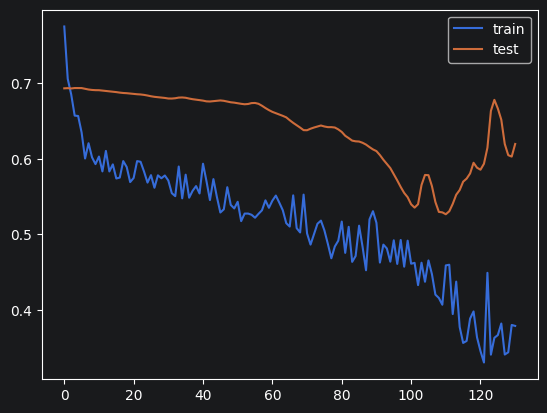

In [14]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()